In [50]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10
%pip install qutip

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math
import qutip as qt

# The BB84 Quantum Key Distribution Protocol
### Part 2: The Intercept-Resend Attack (Eve)

In this scenario, we introduce a malicious eavesdropper, **Eve**. Eve's goal is to intercept the quantum channel, copy the key, and remain undetected.

Because of the **No-Cloning Theorem**, Eve cannot simply duplicate the passing photons. She must measure them. However, just like Bob, Eve does not know which bases Alice used to encode the data. Therefore, Eve must randomly generate her own sequence of bases to guess how to measure the intercepted photons.

In [51]:
# --- PHASE 1: PROTOCOL INITIALIZATION (WITH EVE) ---

NUM_QUBITS = 8

# Alice's preparation
alice_bits = get_quantum_random_bits(NUM_QUBITS)
alice_bases = get_quantum_random_bits(NUM_QUBITS)

# Eve's interception bases (She has to guess, she doesn't know Alice's!)
eve_bases = get_quantum_random_bits(NUM_QUBITS)

# Bob's measurement bases
bob_bases = get_quantum_random_bits(NUM_QUBITS)

print(f"Alice's Raw Bits:       {alice_bits}")
print(f"Alice's Encoding Bases: {alice_bases}")
print(f"Eve's Intercept Bases:  {eve_bases} <--- EVE'S GUESSES")
print(f"Bob's Measuring Bases:  {bob_bases}")

Alice's Raw Bits:       01010001
Alice's Encoding Bases: 11001110
Eve's Intercept Bases:  00011010 <--- EVE'S GUESSES
Bob's Measuring Bases:  11010111


## Phase 2: The Man-in-the-Middle Interception

This is where the physics of quantum mechanics ruins Eve's plans.

1. **Alice Encodes:** Alice prepares her photons normally and sends them.
2. **Eve Intercepts:** Eve catches the photons in transit and measures them using her guessed bases.
    * If Eve guesses the *correct* basis, she reads the bit perfectly and the photon's state remains unchanged.
    * If Eve guesses the *wrong* basis, her measurement forces the photon to collapse into a new state (e.g., snapping a vertical photon down to the diagonal equator).
3. **Eve Resends:** To avoid arousing suspicion, Eve immediately resends the photon to Bob. However, if she guessed the wrong basis, she is sending Bob a *corrupted* photon.

In [52]:
# --- PHASE 2: ENCODING, INTERCEPTION, & TRANSMISSION ---
from qiskit import QuantumRegister, ClassicalRegister

qr = QuantumRegister(NUM_QUBITS, 'q')
cr_eve = ClassicalRegister(NUM_QUBITS, 'eve_meas')
cr_bob = ClassicalRegister(NUM_QUBITS, 'bob_meas')
qc = QuantumCircuit(qr, cr_eve, cr_bob)

# 1. ALICE ENCODES
for i in range(NUM_QUBITS):
    if alice_bits[i] == '1':
        qc.x(i)
    if alice_bases[i] == '1':
        qc.h(i)

qc.barrier() # Entering the exposed quantum fiber optic cable

# 2. EVE INTERCEPTS (The Man-in-the-Middle)
for i in range(NUM_QUBITS):
    # Eve rotates to her guessed basis and measures the photon
    if eve_bases[i] == '1':
        qc.h(i)
    qc.measure(i, cr_eve[i])

    # Eve resends the photon based on her forced measurement
    if eve_bases[i] == '1':
        qc.h(i)

qc.barrier() # Leaving Eve, heading out to Bob

print("Alice encoded -> Eve intercepted and resent -> Qubits heading to Bob.")

Alice encoded -> Eve intercepted and resent -> Qubits heading to Bob.


## Phase 3: Bob's Measurement of Corrupted Qubits

Bob receives the transmission, completely unaware that Eve has tampered with the photons. He proceeds to measure them using his own randomly generated bases.

In the circuit diagram below, we can clearly see Eve wedged between the two barriers—intercepting the qubits from Alice, measuring them into her own classical register (`eve_meas`), and forwarding the collapsed states to Bob's register (`bob_meas`).

Quantum Circuit (Alice -> Eve -> Bob):


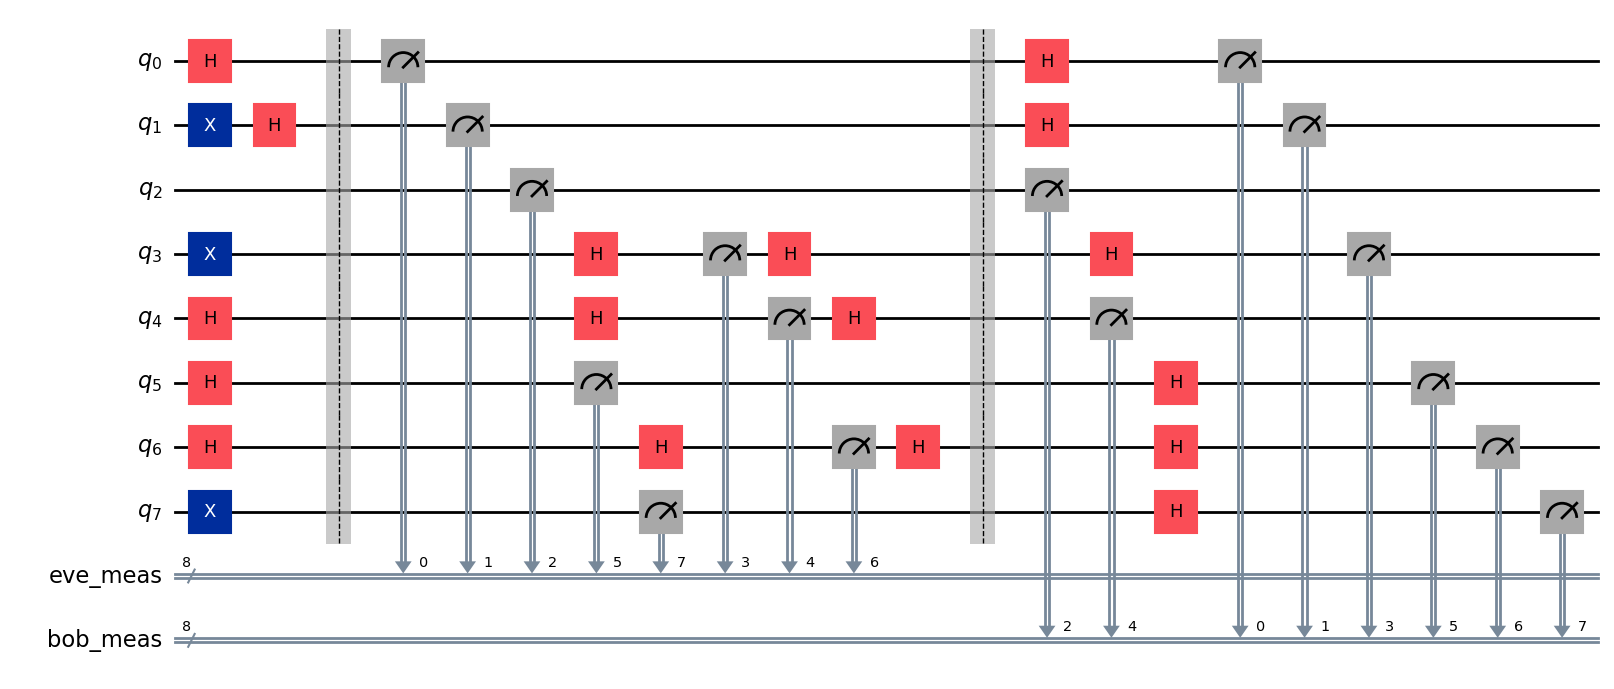


Joint Measurement Results (Format: Bob_bits Eve_bits):


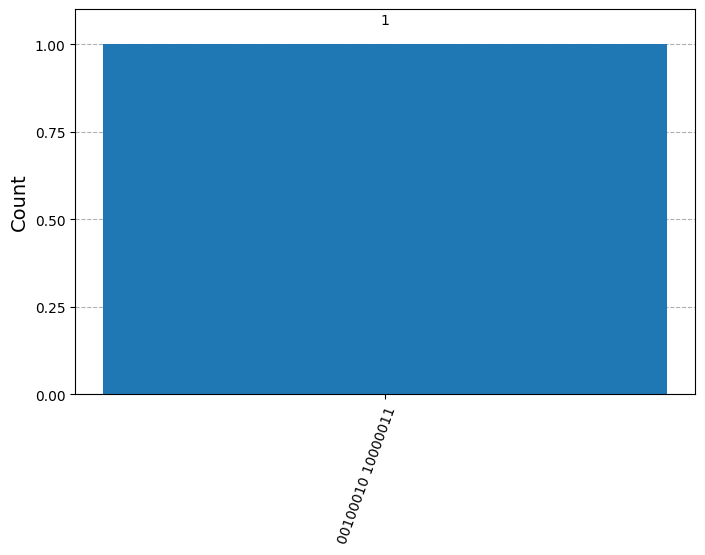

Bob's Raw Bits: 01000100
Eve's Raw Bits: 11000001


In [53]:
# --- PHASE 3: BOB'S MEASUREMENT & VISUALIZATION ---

# 3. BOB MEASURES
for i in range(NUM_QUBITS):
    if bob_bases[i] == '1':
        qc.h(i)
    qc.measure(i, cr_bob[i])

print("Quantum Circuit (Alice -> Eve -> Bob):")
display(qc.draw("mpl"))

# Execute simulation
simulator = BasicSimulator()
t_qc = transpile(qc, simulator)
result = simulator.run(t_qc, shots=1).result()

# Qiskit outputs multi-register data with spaces (e.g., "bob_meas eve_meas")
raw_counts = list(result.get_counts().keys())[0]
bob_res_str, eve_res_str = raw_counts.split(' ')

# Reverse to match array indexing (0 to N-1)
bob_bits = bob_res_str[::-1]
eve_bits = eve_res_str[::-1]

print("\nJoint Measurement Results (Format: Bob_bits Eve_bits):")
display(plot_histogram(result.get_counts(), figsize=(8, 5)))
print(f"Bob's Raw Bits: {bob_bits}")
print(f"Eve's Raw Bits: {eve_bits}")

## Phase 4: Key Sifting

Alice and Bob open their public classical channel. Because they do not yet realize the quantum channel was compromised, they proceed with the standard reconciliation step.

They compare their bases and discard any bits where they did not use the same filters, generating what they believe is a secure sifted key.

In [54]:
# --- PHASE 4: KEY SIFTING ---

alice_key = []
bob_key = []

# Alice and Bob ONLY compare their bases.
for i in range(NUM_QUBITS):
    if alice_bases[i] == bob_bases[i]:
        alice_key.append(alice_bits[i])
        bob_key.append(bob_bits[i])

print(f"Sifted Key Length: {len(alice_key)} bits")
print(f"Alice's Sifted Key: {''.join(alice_key)}")
print(f"Bob's Sifted Key:   {''.join(bob_key)}")

Sifted Key Length: 5 bits
Alice's Sifted Key: 01000
Bob's Sifted Key:   01010


## Phase 5: Error Estimation & Attack Detection

This is where Eve is caught. When Alice and Bob compare their sifted keys, they expect a near 0% error rate. Instead, they will see an error rate spiking around **25%**.

**Why exactly 25%?**
1. Half the time (50%), Eve guesses the wrong basis, corrupting the photon by forcing it onto the wrong axis of the Bloch sphere.
2. When Bob receives that corrupted photon, and measures it in the *correct* basis (because this is the sifted key), quantum mechanics dictates that measuring an orthogonal state yields a completely random 50/50 result.
3. Therefore, Eve causes Bob to read the completely wrong bit $0.50 \times 0.50 = 0.25$ (25%) of the time.

Because this error rate drastically exceeds the safety threshold (10%), Alice and Bob immediately know the channel is compromised, abort the protocol, and throw the compromised keys away. The laws of physics guarantee Eve's detection.

In [55]:
# --- PHASE 5: ERROR ESTIMATION & ATTACK DETECTION ---

# Calculate errors
errors = sum(1 for a, b in zip(alice_key, bob_key) if a != b)
error_rate = errors / len(alice_key) if len(alice_key) > 0 else 0

print(f"Expected Error Rate from Intercept-Resend: ~25.00%")
print(f"Actual Error Rate on Sifted Key:           {error_rate * 100:.2f}%\n")

if error_rate > 0.10: # 10% safety threshold
    print("❌ ALERT: Quantum mechanics violated! High error rate detected.")
    print("❌ The channel is compromised by an eavesdropper. Protocol aborted. Keys discarded.")
else:
    print("✅ SUCCESS: No attack detected. (Note: Statistically highly unlikely to see this if Eve is listening!)")

Expected Error Rate from Intercept-Resend: ~25.00%
Actual Error Rate on Sifted Key:           20.00%

❌ ALERT: Quantum mechanics violated! High error rate detected.
❌ The channel is compromised by an eavesdropper. Protocol aborted. Keys discarded.
